[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/05_feasibility/F1_development_math.ipynb)

# F1: Does It Pencil? Understanding Housing Development Math

---

## Learning Objectives

By the end of this notebook, you will be able to:
1. **Explain why housing is expensive** to build in California
2. **Calculate project costs** including hard costs, soft costs, and land
3. **Estimate rental income** and Net Operating Income (NOI)
4. **Apply the "Does It Pencil?" test** using Yield on Cost
5. **Model policy scenarios** that could make housing more affordable

## Why This Matters

California has a housing crisis. But why don't developers just build more?

The answer: **The math doesn't work.** Many projects simply don't "pencil out" - 
the costs are too high relative to the rents people can pay.

Understanding development math helps you:
- Evaluate claims about housing policy
- Understand why rents are so high
- Identify which policies could actually help
- Have informed conversations about housing in your community

## The Core Question

```
Can a developer build housing, charge rents people can afford,
AND make enough profit to justify the risk?
```

If the answer is NO, housing doesn't get built.

---

## Acknowledgments

This module is based on the [Terner Center for Housing Innovation](https://ternercenter.berkeley.edu/)'s 
excellent "Making It Pencil" framework. We encourage you to explore their 
[interactive development calculator](https://www.ternercenter.app/demystifying-development-math).

---

## Glossary: Key Terms

Before we dive in, let's define terms you'll see throughout:

| Term | Plain English |
|------|---------------|
| **Pro Forma** | A spreadsheet that projects whether a project will be profitable |
| **Hard Costs** | Physical construction: foundation, walls, plumbing, etc. |
| **Soft Costs** | Everything else: permits, fees, architects, lawyers, interest |
| **NOI** | Net Operating Income = Rent collected minus operating expenses |
| **Cap Rate** | Capitalization Rate - the return an investor expects when buying a building |
| **Yield on Cost** | NOI divided by total project cost - the return from *building* |
| **LTC** | Loan-to-Cost ratio - what % the bank will lend |
| **Pencils Out** | Developer slang for "the project is financially feasible" |

---

## 1. Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For interactive widgets
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, Markdown
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("Install ipywidgets for interactive features: pip install ipywidgets")

# Find project root
def find_project_root():
    current = Path.cwd()
    for path in [current] + list(current.parents):
        if (path / '00_config').exists():
            return path
    return current

ROOT = find_project_root()
print(f"Project root: {ROOT}")

Project root: /Users/johngage/berkeley-data


## 2. The Basic Equation

At its core, development math is simple:

```
Value Created  >  Cost to Build  =  Project Makes Sense
Value Created  <  Cost to Build  =  Project Doesn't Happen
```

### How Do We Measure "Value Created"?

For rental housing, value = the stream of future rental income, discounted to today.

The formula:

```
Building Value = Net Operating Income (NOI) / Capitalization Rate (Cap Rate)
```

**Example:** 
- A building generates $500,000/year NOI
- Investors expect a 5% cap rate
- Building value = $500,000 / 0.05 = **$10 million**

---

## 3. Understanding Costs: What Does It Cost to Build?

Development costs break into three buckets:

### 3.1 Hard Costs (60-70% of total)
The physical construction:
- Site preparation and demolition
- Foundation and structure
- Plumbing, electrical, HVAC
- Interior finishes
- Parking (very expensive!)

**Berkeley typical:** $400-600 per square foot

### 3.2 Soft Costs (20-30% of total)
Everything that isn't physical construction:
- Architecture and engineering
- Permits and city fees
- Legal and accounting
- Interest during construction
- Insurance
- Developer overhead

**Berkeley typical:** 25-35% of hard costs

### 3.3 Land Costs (10-20% of total)
What you pay for the dirt:
- Acquisition price
- Closing costs
- Demolition of existing structures

**Berkeley typical:** $150-400 per buildable square foot

In [2]:
@dataclass
class DevelopmentCosts:
    """
    Model the costs to develop a housing project.
    
    All costs are per unit unless otherwise specified.
    Based on Terner Center data for Bay Area mid-rise apartments.
    """
    # Project basics
    num_units: int = 100
    avg_unit_size_sf: int = 750  # square feet per unit
    
    # Hard costs
    hard_cost_per_sf: float = 450  # $/SF construction
    parking_spaces_per_unit: float = 1.0
    parking_cost_per_space: float = 50_000  # structured parking
    
    # Soft costs (as % of hard costs)
    soft_cost_pct: float = 0.30  # 30% of hard costs
    
    # City fees (per unit)
    impact_fees_per_unit: float = 35_000
    permit_fees_per_unit: float = 5_000
    
    # Land
    land_cost_per_unit: float = 100_000
    
    def calculate(self) -> dict:
        """Calculate all costs and return summary."""
        
        # Total building area (units + common areas ~15%)
        gross_sf = self.num_units * self.avg_unit_size_sf * 1.15
        
        # Hard costs
        construction_cost = gross_sf * self.hard_cost_per_sf
        parking_cost = self.num_units * self.parking_spaces_per_unit * self.parking_cost_per_space
        total_hard = construction_cost + parking_cost
        
        # Soft costs
        soft_costs = total_hard * self.soft_cost_pct
        
        # City fees
        city_fees = self.num_units * (self.impact_fees_per_unit + self.permit_fees_per_unit)
        
        # Land
        land_cost = self.num_units * self.land_cost_per_unit
        
        # Totals
        total_cost = total_hard + soft_costs + city_fees + land_cost
        cost_per_unit = total_cost / self.num_units
        
        return {
            'num_units': self.num_units,
            'gross_sf': gross_sf,
            'construction_cost': construction_cost,
            'parking_cost': parking_cost,
            'total_hard_costs': total_hard,
            'soft_costs': soft_costs,
            'city_fees': city_fees,
            'land_cost': land_cost,
            'total_development_cost': total_cost,
            'cost_per_unit': cost_per_unit,
        }
    
    def print_summary(self):
        """Print a formatted cost summary."""
        costs = self.calculate()
        
        print("=" * 50)
        print("DEVELOPMENT COST SUMMARY")
        print("=" * 50)
        print(f"\nProject: {costs['num_units']} units")
        print(f"Building size: {costs['gross_sf']:,.0f} SF")
        print()
        print(f"Hard Costs:")
        print(f"  Construction:     ${costs['construction_cost']:>15,.0f}")
        print(f"  Parking:          ${costs['parking_cost']:>15,.0f}")
        print(f"  Total Hard:       ${costs['total_hard_costs']:>15,.0f}")
        print()
        print(f"Soft Costs:         ${costs['soft_costs']:>15,.0f}")
        print(f"City Fees:          ${costs['city_fees']:>15,.0f}")
        print(f"Land:               ${costs['land_cost']:>15,.0f}")
        print("-" * 50)
        print(f"TOTAL:              ${costs['total_development_cost']:>15,.0f}")
        print(f"Per Unit:           ${costs['cost_per_unit']:>15,.0f}")
        print("=" * 50)

# Example: 100-unit project in Berkeley
project = DevelopmentCosts(num_units=100)
project.print_summary()

DEVELOPMENT COST SUMMARY

Project: 100 units
Building size: 86,250 SF

Hard Costs:
  Construction:     $     38,812,500
  Parking:          $      5,000,000
  Total Hard:       $     43,812,500

Soft Costs:         $     13,143,750
City Fees:          $      4,000,000
Land:               $     10,000,000
--------------------------------------------------
TOTAL:              $     70,956,250
Per Unit:           $        709,562


## 4. Understanding Revenue: What Can the Building Earn?

Revenue comes from rent, but not all rent is profit.

### Net Operating Income (NOI)

```
Gross Potential Rent     (all units at market rent)
- Vacancy Loss           (typically 5% of gross)
= Effective Gross Income
- Operating Expenses     (30-40% of income)
= Net Operating Income (NOI)
```

### Operating Expenses Include:
- Property management (3-5% of rent)
- Property taxes (1-1.5% of value annually)
- Insurance
- Utilities (if not tenant-paid)
- Repairs and maintenance
- Landscaping, cleaning, security

In [3]:
@dataclass
class ProjectRevenue:
    """
    Model the revenue from a rental housing project.
    """
    num_units: int = 100
    monthly_rent_per_unit: float = 3_000  # market rate
    vacancy_rate: float = 0.05  # 5%
    operating_expense_ratio: float = 0.35  # 35% of effective gross
    
    def calculate(self) -> dict:
        """Calculate annual revenue and NOI."""
        
        # Annual gross rent
        annual_gross = self.num_units * self.monthly_rent_per_unit * 12
        
        # Vacancy loss
        vacancy_loss = annual_gross * self.vacancy_rate
        effective_gross = annual_gross - vacancy_loss
        
        # Operating expenses
        operating_expenses = effective_gross * self.operating_expense_ratio
        
        # NOI
        noi = effective_gross - operating_expenses
        
        return {
            'num_units': self.num_units,
            'monthly_rent': self.monthly_rent_per_unit,
            'annual_gross_rent': annual_gross,
            'vacancy_loss': vacancy_loss,
            'effective_gross_income': effective_gross,
            'operating_expenses': operating_expenses,
            'noi': noi,
            'noi_per_unit': noi / self.num_units,
        }
    
    def print_summary(self):
        """Print a formatted revenue summary."""
        rev = self.calculate()
        
        print("=" * 50)
        print("ANNUAL REVENUE SUMMARY")
        print("=" * 50)
        print(f"\nProject: {rev['num_units']} units @ ${rev['monthly_rent']:,.0f}/month")
        print()
        print(f"Gross Potential Rent:    ${rev['annual_gross_rent']:>12,.0f}")
        print(f"Less Vacancy ({self.vacancy_rate*100:.0f}%):       ${rev['vacancy_loss']:>12,.0f}")
        print(f"Effective Gross Income:  ${rev['effective_gross_income']:>12,.0f}")
        print(f"Less Operating Exp ({self.operating_expense_ratio*100:.0f}%): ${rev['operating_expenses']:>12,.0f}")
        print("-" * 50)
        print(f"NET OPERATING INCOME:    ${rev['noi']:>12,.0f}")
        print(f"NOI per Unit:            ${rev['noi_per_unit']:>12,.0f}")
        print("=" * 50)

# Example: 100 units at $3,000/month
revenue = ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
revenue.print_summary()

ANNUAL REVENUE SUMMARY

Project: 100 units @ $3,000/month

Gross Potential Rent:    $   3,600,000
Less Vacancy (5%):       $     180,000
Effective Gross Income:  $   3,420,000
Less Operating Exp (35%): $   1,197,000
--------------------------------------------------
NET OPERATING INCOME:    $   2,223,000
NOI per Unit:            $      22,230


## 5. The Feasibility Test: Does It Pencil?

Now we combine costs and revenue to answer the key question.

### Yield on Cost (Return on Cost)

```
Yield on Cost = NOI / Total Development Cost
```

This measures the return from *building* the project.

### The Test

Compare Yield on Cost to the Cap Rate:

| Yield on Cost vs Cap Rate | Result |
|--------------------------|--------|
| YoC > Cap Rate + 1-2%    | **Project pencils!** Worth the risk to build |
| YoC ≈ Cap Rate           | Marginal - might build with favorable conditions |
| YoC < Cap Rate           | **Doesn't pencil** - cheaper to buy existing |

**Why the premium?** Building is risky - construction delays, cost overruns, 
lease-up time. Developers need extra return to justify that risk.

### Current Market (2024-2025)
- Bay Area cap rates: 4.5-5.5%
- Required yield on cost: 5.5-6.5%
- Many projects: 4.0-5.0% yield = **doesn't pencil**

In [4]:
def feasibility_analysis(costs: DevelopmentCosts, revenue: ProjectRevenue, 
                         cap_rate: float = 0.05, required_spread: float = 0.015):
    """
    Run full feasibility analysis on a project.
    
    Args:
        costs: DevelopmentCosts object
        revenue: ProjectRevenue object
        cap_rate: Market capitalization rate
        required_spread: Premium over cap rate developers need
    """
    cost_data = costs.calculate()
    rev_data = revenue.calculate()
    
    # Yield on cost
    yield_on_cost = rev_data['noi'] / cost_data['total_development_cost']
    
    # Required yield
    required_yield = cap_rate + required_spread
    
    # Building value (if it were to sell)
    building_value = rev_data['noi'] / cap_rate
    
    # Profit (or loss)
    profit = building_value - cost_data['total_development_cost']
    profit_margin = profit / cost_data['total_development_cost']
    
    # Does it pencil?
    pencils = yield_on_cost >= required_yield
    
    print("=" * 60)
    print("FEASIBILITY ANALYSIS: DOES IT PENCIL?")
    print("=" * 60)
    print(f"\nProject: {cost_data['num_units']} units")
    print(f"Monthly Rent: ${rev_data['monthly_rent']:,.0f}")
    print()
    print(f"Total Development Cost:  ${cost_data['total_development_cost']:>15,.0f}")
    print(f"Annual NOI:              ${rev_data['noi']:>15,.0f}")
    print(f"Building Value:          ${building_value:>15,.0f}")
    print()
    print(f"Yield on Cost:           {yield_on_cost*100:>14.2f}%")
    print(f"Market Cap Rate:         {cap_rate*100:>14.2f}%")
    print(f"Required Yield:          {required_yield*100:>14.2f}%")
    print()
    print(f"Profit/(Loss):           ${profit:>15,.0f}")
    print(f"Profit Margin:           {profit_margin*100:>14.1f}%")
    print()
    print("-" * 60)
    if pencils:
        print("RESULT: PROJECT PENCILS! Worth building.")
    else:
        gap = required_yield - yield_on_cost
        print(f"RESULT: DOES NOT PENCIL. Gap: {gap*100:.2f}%")
        
        # What rent would be needed?
        required_noi = cost_data['total_development_cost'] * required_yield
        required_egi = required_noi / (1 - revenue.operating_expense_ratio)
        required_gross = required_egi / (1 - revenue.vacancy_rate)
        required_rent = required_gross / (revenue.num_units * 12)
        print(f"Rent needed to pencil: ${required_rent:,.0f}/month")
        print(f"(Current: ${rev_data['monthly_rent']:,.0f}/month)")
    print("=" * 60)
    
    return {
        'yield_on_cost': yield_on_cost,
        'cap_rate': cap_rate,
        'required_yield': required_yield,
        'building_value': building_value,
        'profit': profit,
        'pencils': pencils
    }

# Run feasibility on our example
project_costs = DevelopmentCosts(num_units=100)
project_revenue = ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)

result = feasibility_analysis(project_costs, project_revenue)

FEASIBILITY ANALYSIS: DOES IT PENCIL?

Project: 100 units
Monthly Rent: $3,000

Total Development Cost:  $     70,956,250
Annual NOI:              $      2,223,000
Building Value:          $     44,460,000

Yield on Cost:                     3.13%
Market Cap Rate:                   5.00%
Required Yield:                    6.50%

Profit/(Loss):           $    -26,496,250
Profit Margin:                    -37.3%

------------------------------------------------------------
RESULT: DOES NOT PENCIL. Gap: 3.37%
Rent needed to pencil: $6,224/month
(Current: $3,000/month)


## 6. Policy Scenarios: What Could Make Housing Pencil?

Let's model different policy interventions and see their impact.

### Scenario Options:
1. **Reduce parking requirements** - Parking costs $50K+ per space
2. **Lower impact fees** - Berkeley charges ~$35K per unit
3. **Increase density** - More units spreads land cost
4. **Reduce construction costs** - Modular, prefab, or streamlined codes
5. **Higher rents** - Only works if people can afford them

In [5]:
def compare_scenarios():
    """Compare different policy scenarios."""
    
    scenarios = {
        'Baseline': {
            'costs': DevelopmentCosts(num_units=100),
            'revenue': ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
        },
        'No Parking': {
            'costs': DevelopmentCosts(num_units=100, parking_spaces_per_unit=0),
            'revenue': ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
        },
        'Half Parking': {
            'costs': DevelopmentCosts(num_units=100, parking_spaces_per_unit=0.5),
            'revenue': ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
        },
        'Lower Fees ($10K)': {
            'costs': DevelopmentCosts(num_units=100, impact_fees_per_unit=10_000),
            'revenue': ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
        },
        '+25% Density': {
            'costs': DevelopmentCosts(num_units=125, land_cost_per_unit=80_000),  # same land, more units
            'revenue': ProjectRevenue(num_units=125, monthly_rent_per_unit=3_000)
        },
        '-10% Hard Costs': {
            'costs': DevelopmentCosts(num_units=100, hard_cost_per_sf=405),
            'revenue': ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
        },
        'All Reforms': {
            'costs': DevelopmentCosts(
                num_units=125,
                parking_spaces_per_unit=0.25,
                impact_fees_per_unit=10_000,
                hard_cost_per_sf=405,
                land_cost_per_unit=80_000
            ),
            'revenue': ProjectRevenue(num_units=125, monthly_rent_per_unit=3_000)
        },
    }
    
    results = []
    
    for name, scenario in scenarios.items():
        cost_data = scenario['costs'].calculate()
        rev_data = scenario['revenue'].calculate()
        
        yoc = rev_data['noi'] / cost_data['total_development_cost']
        
        results.append({
            'Scenario': name,
            'Units': cost_data['num_units'],
            'Total Cost ($M)': cost_data['total_development_cost'] / 1_000_000,
            'Cost/Unit ($K)': cost_data['cost_per_unit'] / 1_000,
            'NOI ($M)': rev_data['noi'] / 1_000_000,
            'Yield on Cost': f"{yoc*100:.2f}%",
            'Pencils?': 'YES' if yoc >= 0.065 else 'NO'
        })
    
    df = pd.DataFrame(results)
    print("\nSCENARIO COMPARISON (Required Yield: 6.5%)\n")
    print(df.to_string(index=False))
    return df

scenario_results = compare_scenarios()


SCENARIO COMPARISON (Required Yield: 6.5%)

         Scenario  Units  Total Cost ($M)  Cost/Unit ($K)  NOI ($M) Yield on Cost Pencils?
         Baseline    100        70.956250       709.56250   2.22300         3.13%       NO
       No Parking    100        64.456250       644.56250   2.22300         3.45%       NO
     Half Parking    100        67.706250       677.06250   2.22300         3.28%       NO
Lower Fees ($10K)    100        68.456250       684.56250   2.22300         3.25%       NO
     +25% Density    125        86.195312       689.56250   2.77875         3.22%       NO
  -10% Hard Costs    100        65.910625       659.10625   2.22300         3.37%       NO
      All Reforms    125        70.669531       565.35625   2.77875         3.93%       NO


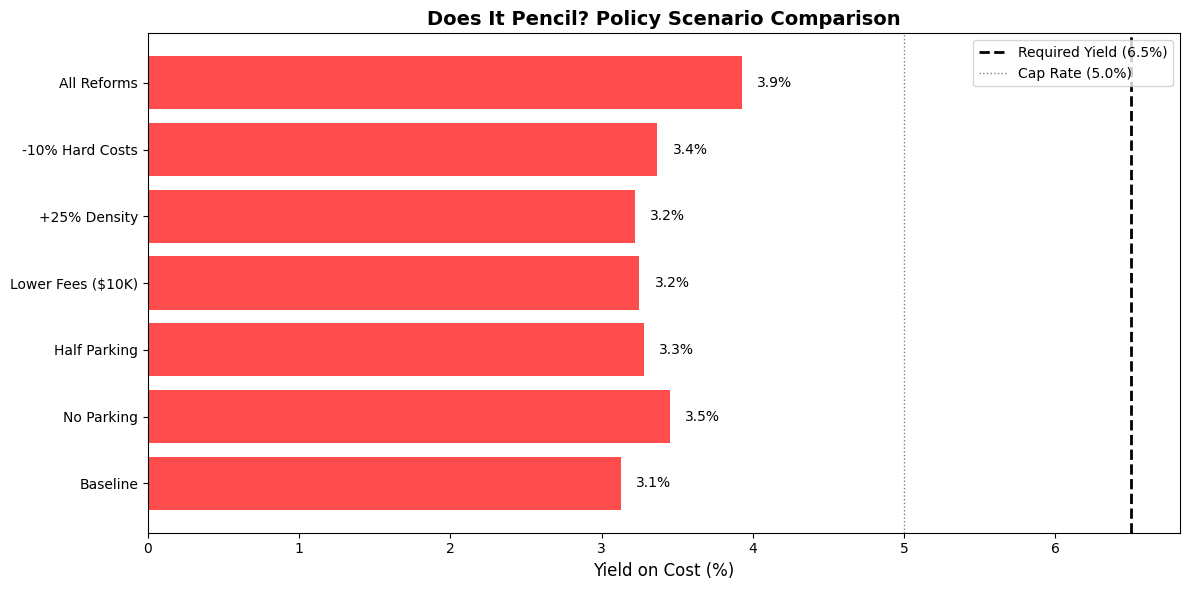

In [6]:
# Visualize scenarios
def plot_scenarios(df):
    """Plot yield on cost for each scenario."""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Extract yield values
    yields = [float(y.strip('%')) for y in df['Yield on Cost']]
    scenarios = df['Scenario'].tolist()
    colors = ['green' if y >= 6.5 else 'red' for y in yields]
    
    bars = ax.barh(scenarios, yields, color=colors, alpha=0.7)
    
    # Add threshold line
    ax.axvline(x=6.5, color='black', linestyle='--', linewidth=2, label='Required Yield (6.5%)')
    ax.axvline(x=5.0, color='gray', linestyle=':', linewidth=1, label='Cap Rate (5.0%)')
    
    # Labels
    ax.set_xlabel('Yield on Cost (%)', fontsize=12)
    ax.set_title('Does It Pencil? Policy Scenario Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    
    # Add value labels
    for bar, val in zip(bars, yields):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

plot_scenarios(scenario_results)

## 7. Interactive Calculator

Now it's your turn! Adjust the inputs and see how they affect feasibility.

**Try these experiments:**
1. What rent is needed for the baseline project to pencil?
2. How much do parking requirements really cost?
3. What if construction costs drop 20%?
4. Can affordable housing ($1,500/month) ever pencil without subsidy?

In [7]:
if HAS_WIDGETS:
    # Create interactive widgets
    
    style = {'description_width': '180px'}
    layout = widgets.Layout(width='400px')
    
    # Input widgets
    w_units = widgets.IntSlider(value=100, min=10, max=500, step=10,
                                description='Number of Units:', style=style, layout=layout)
    w_rent = widgets.IntSlider(value=3000, min=1000, max=5000, step=100,
                               description='Monthly Rent ($):', style=style, layout=layout)
    w_parking = widgets.FloatSlider(value=1.0, min=0, max=2.0, step=0.25,
                                    description='Parking Spaces/Unit:', style=style, layout=layout)
    w_hard_cost = widgets.IntSlider(value=450, min=300, max=700, step=25,
                                    description='Hard Cost ($/SF):', style=style, layout=layout)
    w_impact_fees = widgets.IntSlider(value=35000, min=0, max=75000, step=5000,
                                      description='Impact Fees ($/unit):', style=style, layout=layout)
    w_land_cost = widgets.IntSlider(value=100000, min=25000, max=250000, step=25000,
                                    description='Land Cost ($/unit):', style=style, layout=layout)
    
    output = widgets.Output()
    
    def update_calc(change):
        output.clear_output()
        with output:
            costs = DevelopmentCosts(
                num_units=w_units.value,
                hard_cost_per_sf=w_hard_cost.value,
                parking_spaces_per_unit=w_parking.value,
                impact_fees_per_unit=w_impact_fees.value,
                land_cost_per_unit=w_land_cost.value
            )
            revenue = ProjectRevenue(
                num_units=w_units.value,
                monthly_rent_per_unit=w_rent.value
            )
            feasibility_analysis(costs, revenue)
    
    # Connect widgets to update function
    for w in [w_units, w_rent, w_parking, w_hard_cost, w_impact_fees, w_land_cost]:
        w.observe(update_calc, names='value')
    
    # Display
    print("Adjust the sliders to see how different factors affect feasibility:\n")
    display(widgets.VBox([
        widgets.HTML('<h4>Project Parameters</h4>'),
        w_units, w_rent,
        widgets.HTML('<h4>Cost Factors</h4>'),
        w_parking, w_hard_cost, w_impact_fees, w_land_cost,
        widgets.HTML('<h4>Results</h4>'),
        output
    ]))
    
    # Initial calculation
    update_calc(None)
else:
    print("Interactive widgets not available.")
    print("Install with: pip install ipywidgets")
    print("\nRunning static example instead:\n")
    
    costs = DevelopmentCosts(num_units=100)
    revenue = ProjectRevenue(num_units=100, monthly_rent_per_unit=3_000)
    feasibility_analysis(costs, revenue)

Adjust the sliders to see how different factors affect feasibility:



## 8. Berkeley Case Studies

Let's apply this framework to real Berkeley projects from our database.

In [8]:
import sqlite3

# Load Berkeley projects
db_path = ROOT / 'databases/berkeley_housing_analysis.db'

if db_path.exists():
    conn = sqlite3.connect(db_path)
    
    # Get largest projects
    df_projects = pd.read_sql_query("""
        SELECT address_display, net_units, status, year
        FROM projects
        WHERE net_units >= 50
        ORDER BY net_units DESC
        LIMIT 10
    """, conn)
    
    conn.close()
    
    print("Berkeley's Largest Proposed Projects:\n")
    display(df_projects)
    
    # Model feasibility for each
    print("\n" + "="*70)
    print("FEASIBILITY ESTIMATES (using market assumptions)")
    print("="*70)
    
    feasibility_results = []
    
    for _, project in df_projects.iterrows():
        units = int(project['net_units'])
        
        # Estimate costs (larger projects have slightly lower per-unit costs)
        scale_factor = 1.0 - min(0.15, (units - 50) / 1000)  # up to 15% discount for scale
        
        costs = DevelopmentCosts(
            num_units=units,
            hard_cost_per_sf=int(450 * scale_factor)
        )
        revenue = ProjectRevenue(
            num_units=units,
            monthly_rent_per_unit=3_200  # Berkeley market rate
        )
        
        cost_data = costs.calculate()
        rev_data = revenue.calculate()
        yoc = rev_data['noi'] / cost_data['total_development_cost']
        
        feasibility_results.append({
            'Address': project['address_display'][:30],
            'Units': units,
            'Est. Cost ($M)': f"${cost_data['total_development_cost']/1e6:.1f}M",
            'Yield on Cost': f"{yoc*100:.1f}%",
            'Pencils?': 'YES' if yoc >= 0.065 else 'NO',
            'Status': project['status']
        })
    
    df_feasibility = pd.DataFrame(feasibility_results)
    print()
    print(df_feasibility.to_string(index=False))
    
else:
    print(f"Database not found at {db_path}")
    print("Run the data collection notebooks first.")

Berkeley's Largest Proposed Projects:



,address_display,net_units,status,year
0,1750 SACRAMENTO St,739.0,Under Review,2024.0
1,2276 SHATTUCK Ave,336.0,In Review,2024.0
2,2700 SHATTUCK Ave,276.0,In Review,2024.0
3,1914 FIFTH St,257.0,Under Review,2020.0
4,2425 DURANT Ave,250.0,Pending Final Action,2024.0
5,2029 UNIVERSITY Ave,240.0,Pending Final Action,2024.0
6,2601 SAN PABLO Ave,223.0,In Review,2022.0
7,2920 SHATTUCK Ave,221.0,In Review,2022.0
8,1899 OXFORD St,212.0,Pending Final Action,2024.0
9,3000 SHATTUCK Ave,166.0,In Review,2022.0



FEASIBILITY ESTIMATES (using market assumptions)

            Address  Units Est. Cost ($M) Yield on Cost Pencils?               Status
 1750 SACRAMENTO St    739        $468.0M          3.7%       NO         Under Review
  2276 SHATTUCK Ave    336        $212.8M          3.7%       NO            In Review
  2700 SHATTUCK Ave    276        $174.8M          3.7%       NO            In Review
      1914 FIFTH St    257        $162.8M          3.7%       NO         Under Review
    2425 DURANT Ave    250        $158.3M          3.7%       NO Pending Final Action
2029 UNIVERSITY Ave    240        $152.0M          3.7%       NO Pending Final Action
 2601 SAN PABLO Ave    223        $141.2M          3.7%       NO            In Review
  2920 SHATTUCK Ave    221        $140.0M          3.7%       NO            In Review
     1899 OXFORD St    212        $134.3M          3.7%       NO Pending Final Action
  3000 SHATTUCK Ave    166        $107.9M          3.6%       NO            In Review


## 9. Exercises

### Exercise 1: Affordable Housing Math
If affordable housing rents are $1,500/month (50% of market), what subsidy per unit 
is needed to make the project pencil?

### Exercise 2: Your City
Research construction costs and rents in your city. Does new housing pencil there? 
What policies could help?

### Exercise 3: Historical Comparison
Construction costs have risen ~40% since 2020. Model a project with 2020 costs 
($320/SF hard costs) vs. today. How much has feasibility changed?

### Exercise 4: Interest Rate Sensitivity
Higher interest rates increase soft costs (construction loans cost more). 
Model soft costs at 25%, 30%, and 35% of hard costs. How sensitive is feasibility?

In [9]:
# Space for your exercises

# Exercise 1: Affordable Housing
# Hint: Calculate the gap between NOI at $1,500 rent and NOI needed to pencil

affordable_revenue = ProjectRevenue(num_units=100, monthly_rent_per_unit=1_500)
market_costs = DevelopmentCosts(num_units=100)

# Your analysis here:


## 10. Summary

### Key Takeaways

1. **Development math is simple in concept**: Revenue - Costs = Profit

2. **But the numbers often don't work**: High construction costs, expensive land, 
   and city fees make many projects infeasible

3. **Yield on Cost is the key metric**: Must exceed cap rate + risk premium to pencil

4. **Policy levers exist**: Parking reform, fee reduction, density bonuses, and 
   construction innovation can all help

5. **No single solution**: Stacking multiple reforms is often necessary

6. **Affordable housing requires subsidy**: At below-market rents, projects can't 
   pencil without public investment

### Resources

- [Terner Center: Making It Pencil](https://ternercenter.berkeley.edu/research-and-policy/making-it-pencil-2023/)
- [Interactive Development Calculator](https://www.ternercenter.app/demystifying-development-math)
- [Policy Gauge Dashboard](https://ternercenter.berkeley.edu/policy-gauge-dashboard/)

---

**Next:** Apply this analysis to specific Berkeley projects in F2_project_pro_forma.ipynb